In [1]:
import torch
import CT.Models.Unet as Unet
import CT.Models.diffusion as diffusion
import CT.Models.misc as misc

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
file_string = "/scratch/ql2221/thermalizer_data/wandb_data/wandb/run-20251103_130233-5fse3foa/files/checkpoint_last.p"

DM = misc.load_diffusion_model(file_string).to(device)

In [3]:
#load data
data_dict = torch.load("/scratch/ql2221/thermalizer_data/kolmogorov/reynold10k/Long_numerical_rollout.p")
data = data_dict["data"]
print(data.shape)

torch.Size([5, 50000, 64, 64])


In [4]:
x = data[0:1].to(device)/4.44

#getting x_t and noise it
x_t = x[:,-1:]
noise = torch.randn_like(x[:,-1:]).to(device)
s = 500
x_t_noised = DM._forward_diffusion(x_t, s, noise).to(device)

In [5]:
short_lag = torch.tensor([2]).to(device)
long_lag = torch.tensor([100]).to(device)
x_t_minus_short_lag = x[:,-(short_lag*25)-1:-(short_lag*25)].to(device)
x_t_minus_short_lag = DM._forward_diffusion(x_t_minus_short_lag, s, noise).to(device)
x_t_minus_long_lag = x[:,-(long_lag*25)-1:-(long_lag*25)].to(device)
x_conditional = torch.cat((x_t_noised, x_t_minus_short_lag, x_t_minus_long_lag), dim=1).to(device)

x_denoised = DM.denoising(x_conditional, short_lag, long_lag, s)

Denoising: 100%|██████████| 500/500 [00:09<00:00, 53.09it/s]


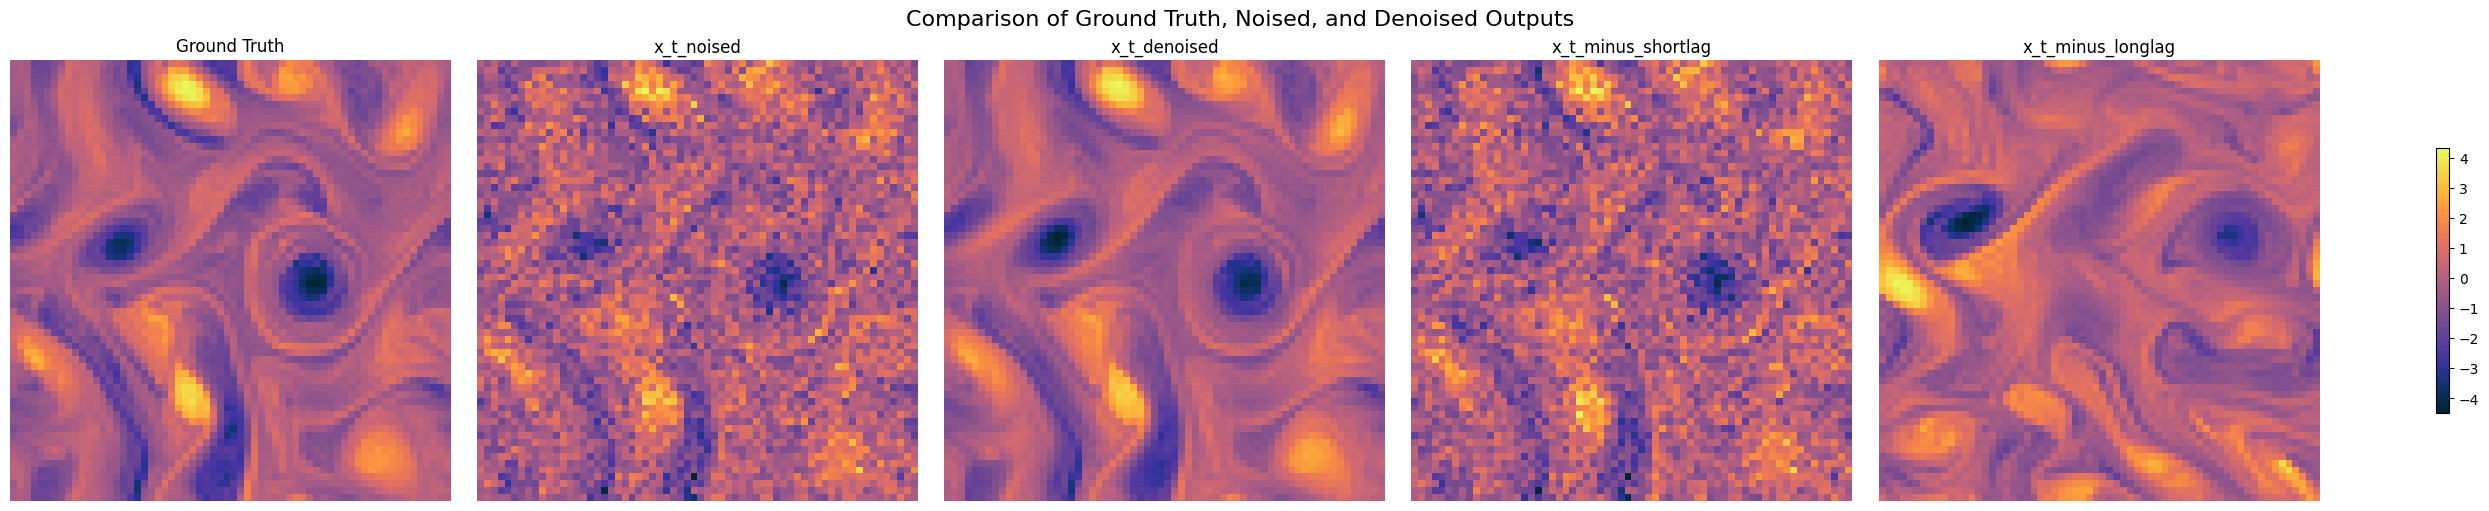

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean

tensors = [
    x_t,                
    x_t_noised,
    x_denoised,
    x_t_minus_short_lag,
    x_t_minus_long_lag
]
titles = [
    'Ground Truth',
    'x_t_noised',
    'x_t_denoised',
    'x_t_minus_shortlag',
    'x_t_minus_longlag'
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

plt.savefig("comparison_diffusion.png", dpi=300, bbox_inches='tight')
plt.show()


In [27]:
#sensitivity analysis on the UUnet
x_t = x[:,-1:]
noise = torch.randn_like(x[:,-1:]).to(device)
noise_level = 500
t = torch.tensor([noise_level], dtype=torch.int64).to(device)
x_t_noised = DM._forward_diffusion(x_t,t,noise)
x_t_noised = x_t_noised.to(device)

deltas = np.arange(1,127)
grad_mag = []

for delta in deltas:
    delta_tensor = torch.tensor([delta], dtype=torch.float32).to(device)
    x_t_minus = x[:,-1-delta:-delta]
    delta_tensor.requires_grad_()
    x_t_minus = x_t_minus.to(device)
    x_conditional = torch.cat((x_t_noised, x_t_minus), dim=1)
    x_conditional = x_conditional.to(device)
    x_pred = UUnet.model(x_conditional,delta_tensor,t)
    loss = torch.norm(x_pred)
    loss.backward()
    sensitivity = delta_tensor.grad.abs().item()
    grad_mag.append(sensitivity)

plt.figure(figsize=(10, 5))
plt.plot(deltas, grad_mag, marker='o')
plt.title("Sensitivity of UUnet Output to Δ (delta)")
plt.xlabel("Δ (delta)")
plt.ylabel("Gradient Magnitude w.r.t Δ")
plt.grid(True)
plt.tight_layout()
plt.savefig("sensitivity_plot.png", dpi=300)
plt.show()

NameError: name 'UUnet' is not defined